<a href="https://colab.research.google.com/github/hridyavv/AI-Based-Smoke-Detection-System-Using-Machine-Learning/blob/main/lab_aiot_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIoT
====

Introduction into classification with smoke detector dataset.

First import required packages

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn import metrics
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier

Import data
-----------
Import csv file of labeled smoke detector readings as pandas dataframe.

In [ ]:
df = pd.read_csv("/smoke_detection_iot.csv", index_col = 0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Explore data
------------
Use pandas and DataWrangler to explore the dataset you just loaded

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62630 entries, 0 to 62629
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UTC             62630 non-null  int64  
 1   Temperature[C]  62630 non-null  float64
 2   Humidity[%]     62630 non-null  float64
 3   TVOC[ppb]       62630 non-null  int64  
 4   eCO2[ppm]       62630 non-null  int64  
 5   Raw H2          62630 non-null  int64  
 6   Raw Ethanol     62630 non-null  int64  
 7   Pressure[hPa]   62630 non-null  float64
 8   PM1.0           62630 non-null  float64
 9   PM2.5           62630 non-null  float64
 10  NC0.5           62630 non-null  float64
 11  NC1.0           62630 non-null  float64
 12  NC2.5           62630 non-null  float64
 13  CNT             62630 non-null  int64  
 14  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int64(7)
memory usage: 7.6 MB


In [ ]:
df.describe()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,6.263000e+04,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,1.654792e+09,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,10511.386157,0.714626
std,1.100025e+05,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,7597.870997,0.451596
min,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.654743e+09,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000,0.000000
50%,1.654762e+09,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,9336.000000,1.000000
75%,1.654778e+09,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000,1.000000
max,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000,1.000000


Convert the Fire Alarm label to a suitable unit

In [ ]:
df["Fire Alarm"] = df["Fire Alarm"].astype("bool")
df["UTC"] = pd.to_datetime(df["UTC"], unit = "s")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62630 entries, 0 to 62629
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   UTC             62630 non-null  datetime64[ns]
 1   Temperature[C]  62630 non-null  float64       
 2   Humidity[%]     62630 non-null  float64       
 3   TVOC[ppb]       62630 non-null  int64         
 4   eCO2[ppm]       62630 non-null  int64         
 5   Raw H2          62630 non-null  int64         
 6   Raw Ethanol     62630 non-null  int64         
 7   Pressure[hPa]   62630 non-null  float64       
 8   PM1.0           62630 non-null  float64       
 9   PM2.5           62630 non-null  float64       
 10  NC0.5           62630 non-null  float64       
 11  NC1.0           62630 non-null  float64       
 12  NC2.5           62630 non-null  float64       
 13  CNT             62630 non-null  int64         
 14  Fire Alarm      62630 non-null  bool          
dtypes: bool

In [ ]:
df

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,2022-06-09 00:08:51,20.000,57.36,0,400,12306,18520,939.735,0.00,0.00,0.00,0.000,0.000,0,False
1,2022-06-09 00:08:52,20.015,56.67,0,400,12345,18651,939.744,0.00,0.00,0.00,0.000,0.000,1,False
2,2022-06-09 00:08:53,20.029,55.96,0,400,12374,18764,939.738,0.00,0.00,0.00,0.000,0.000,2,False
3,2022-06-09 00:08:54,20.044,55.28,0,400,12390,18849,939.736,0.00,0.00,0.00,0.000,0.000,3,False
4,2022-06-09 00:08:55,20.059,54.69,0,400,12403,18921,939.744,0.00,0.00,0.00,0.000,0.000,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62625,2022-06-13 14:20:47,18.438,15.79,625,400,13723,20569,936.670,0.63,0.65,4.32,0.673,0.015,5739,False
62626,2022-06-13 14:20:48,18.653,15.87,612,400,13731,20588,936.678,0.61,0.63,4.18,0.652,0.015,5740,False
62627,2022-06-13 14:20:49,18.867,15.84,627,400,13725,20582,936.687,0.57,0.60,3.95,0.617,0.014,5741,False
62628,2022-06-13 14:20:50,19.083,16.04,638,400,13712,20566,936.680,0.57,0.59,3.92,0.611,0.014,5742,False


<Axes: xlabel='Fire Alarm', ylabel='count'>

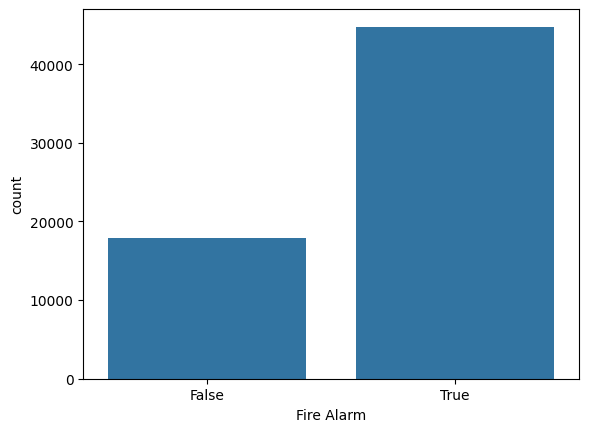

In [ ]:
sns.countplot(x = "Fire Alarm", data = df)

Show correlation between the features, esp. interesting with regards to the label.

<Axes: >

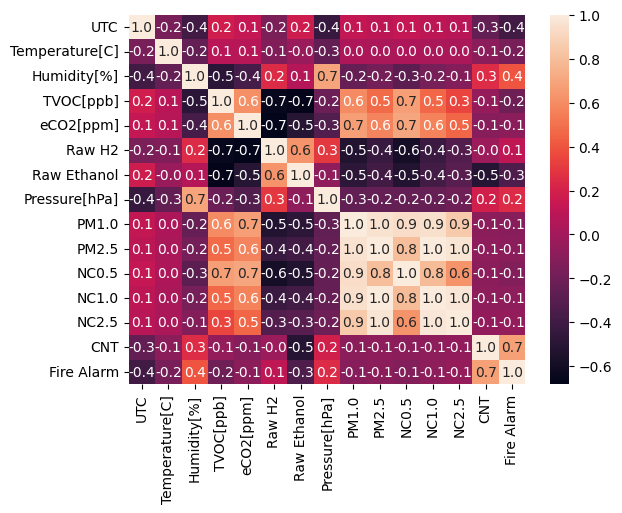

In [ ]:
sns.heatmap(df.corr(), annot = True, fmt = "0.1f")

<Axes: xlabel='UTC', ylabel='Count'>

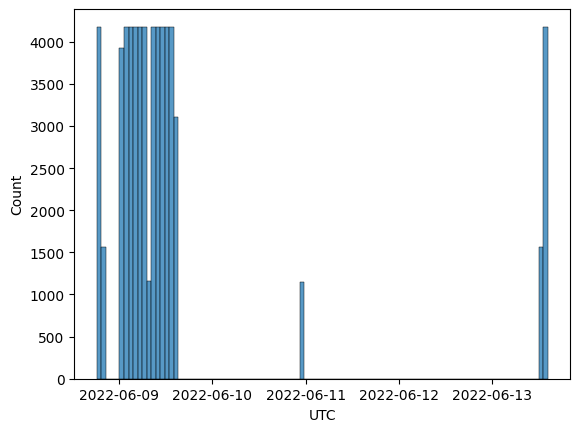

In [ ]:
sns.histplot(df["UTC"], bins = 100)

Normalization
-------------

split data:
- features/label and for training/validation.
- Remove time
- use a test size of 20%

In [ ]:
x = df.drop(columns = ["Fire Alarm", "UTC"])
y = df["Fire Alarm"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state=0)

normalize/standardize

In [ ]:
x_train

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT
46354,24.330,54.03,1320,401,12961,19396,938.696,1.90,1.98,13.11,2.044,0.046,21360
25723,12.400,55.88,11,400,12919,19857,939.742,0.31,0.32,2.13,0.332,0.007,729
28588,20.090,57.90,335,400,13099,19874,939.670,1.44,1.50,9.93,1.548,0.035,3594
33302,18.400,56.44,326,400,13100,19935,939.376,0.41,0.43,2.85,0.444,0.010,8308
8971,-5.217,55.91,363,400,13061,19904,939.279,0.33,0.34,2.27,0.354,0.008,8971
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24094,-12.240,49.01,1186,400,13025,19424,938.762,2.48,2.57,17.05,2.659,0.060,24094
22330,-17.167,49.13,1333,400,12971,19399,938.698,2.00,2.07,13.74,2.143,0.048,22330
14609,14.743,47.01,1140,470,12861,19448,938.880,1.96,2.04,13.51,2.107,0.048,14609
33172,19.230,50.98,320,400,13099,19943,939.382,0.24,0.25,1.64,0.256,0.006,8178


In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)


In [ ]:
x_train

array([[ 0.58019034,  0.61870128, -0.08186015, ..., -0.09188293,
        -0.07493939,  1.42927036],
       [-0.24958852,  0.82650817, -0.24783266, ..., -0.09263866,
        -0.07497447, -1.2871956 ],
       [ 0.28528151,  1.05341082, -0.20675161, ..., -0.09210188,
        -0.07494928, -0.90996352],
       ...,
       [-0.08662357, -0.1698416 , -0.10468295, ..., -0.09185512,
        -0.07493759,  0.54037202],
       [ 0.22546509,  0.27610074, -0.20865351, ..., -0.09267221,
        -0.07497537, -0.3063922 ],
       [ 0.32770943,  0.29968963, -0.20916069, ..., -0.09261924,
        -0.07497267, -0.28637849]])

In [ ]:
norm = Normalizer()
x_train = norm.fit_transform(x_train)
x_test = norm.fit_transform(x_test)

In [ ]:
x_train

array([[ 0.32497431,  0.34654493, -0.04585124, ..., -0.05146517,
        -0.0419748 ,  0.80055823],
       [-0.13810014,  0.45731626, -0.1371286 , ..., -0.05125801,
        -0.04148422, -0.7122198 ],
       [ 0.16181773,  0.597517  , -0.11727391, ..., -0.05224214,
        -0.04251282, -0.51615064],
       ...,
       [-0.09847061, -0.19306993, -0.11899988, ..., -0.10441765,
        -0.0851864 ,  0.6142758 ],
       [ 0.21708552,  0.26583926, -0.20089875, ..., -0.08922798,
        -0.07218886, -0.29500492],
       [ 0.30877282,  0.28237214, -0.19707439, ..., -0.08726726,
        -0.07064039, -0.26983018]])

Classification - Scikit-learn
-----------------------------

Use SVC. Try and evaluate different kernels

In [ ]:
clf_svm = svm.SVC(kernel = "linear")
clf_svm.fit(x_train, y_train)

pred_svm = clf_svm.predict(x_test)

evaluate using accuracy, precision, recall and confusion matrix

In [ ]:
acc_svm = metrics.accuracy_score(y_test, pred_svm)
prec_svm = metrics.precision_score(y_test, pred_svm)
rec_svm = metrics.recall_score(y_test, pred_svm)
print(f"Accuracy:\t{acc_svm}\nPrecision:\t{prec_svm}\nRecall:\t\t{rec_svm}")

Accuracy:	0.9826760338495929
Precision:	0.9935578661844484
Recall:		0.9821249022455592


In [ ]:
metrics.confusion_matrix(y_test, pred_svm)

array([[3518,   57],
       [ 160, 8791]])

In [ ]:
print(metrics.classification_report(y_test, pred_svm))

              precision    recall  f1-score   support

       False       0.96      0.98      0.97      3575
        True       0.99      0.98      0.99      8951

    accuracy                           0.98     12526
   macro avg       0.98      0.98      0.98     12526
weighted avg       0.98      0.98      0.98     12526



SVM with linear kernel can show the most influental features.

In [ ]:
clf_svm.coef_

array([[ -0.66605431,   2.16316103, -34.62481323,   9.55187836,
          1.29204423,  -4.33672441,   0.66749095,  -0.05447407,
         -0.93124491,   0.98558551,  -0.98954316,  -1.59773443,
         13.26946548]])

Tracks with the correlation from above -> dataseries/batching are messing with the prediction.
Best to remove the cnt feature!

Use a Random Forest classifier and compare it with the SVM

In [ ]:
clf_rf = RandomForestClassifier()
clf_rf.fit(x_train, y_train)

pred_rf = clf_rf.predict(x_test)

In [ ]:
print(metrics.classification_report(y_test, pred_rf))
print(metrics.confusion_matrix(y_test, pred_rf))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99      3575
        True       1.00      0.99      1.00      8951

    accuracy                           1.00     12526
   macro avg       0.99      1.00      0.99     12526
weighted avg       1.00      1.00      1.00     12526

[[3574    1]
 [  58 8893]]


In [ ]:
clf_rf.feature_importances_

array([0.02797148, 0.06557039, 0.06246866, 0.01150247, 0.04577419,
       0.10424739, 0.21876883, 0.0276626 , 0.02482708, 0.01633372,
       0.04070575, 0.0569309 , 0.29723653])

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Activation, BatchNormalization
from tensorflow.keras.utils import plot_model

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [ ]:
model = Sequential([
    Dense(128, activation = "relu"),
    Dense(10),
    BatchNormalization(),
    Dense(2)
])

In [ ]:
pred_keras = model(x_train[:1]).numpy()
pred_keras

array([[-0.02163262,  0.10326181]], dtype=float32)

In [ ]:
tf.nn.softmax(pred_keras).numpy()

array([[0.46881688, 0.53118306]], dtype=float32)

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
loss_fn(y_train[:1], pred_keras).numpy()

np.float32(0.6326485)

In [ ]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [ ]:
hist = model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9830 - loss: 0.0679
Epoch 2/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9976 - loss: 0.0092
Epoch 3/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9988 - loss: 0.0077
Epoch 4/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9985 - loss: 0.0068
Epoch 5/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9988 - loss: 0.0049
Epoch 6/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9988 - loss: 0.0048
Epoch 7/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9990 - loss: 0.0043
Epoch 8/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9991 - loss: 0.0038
Epoch 9/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9989 - loss: 0.0045
Epoch 10/10
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9989 - loss: 0.0043


In [ ]:
model.evaluate(x_test,  y_test, verbose=2, return_dict = True)

392/392 - 1s - 3ms/step - accuracy: 0.9994 - loss: 0.0038


{'accuracy': 0.9994411468505859, 'loss': 0.0038344403728842735}

<Axes: >

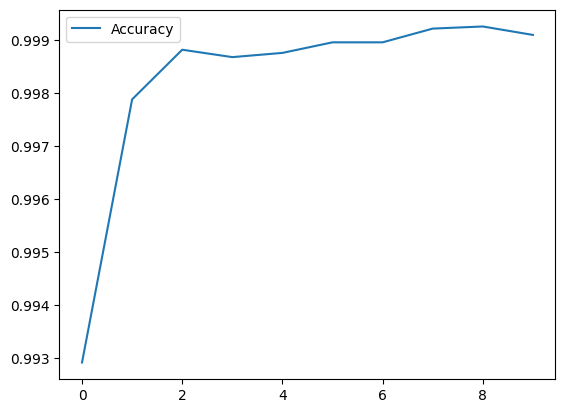

In [ ]:
sns.lineplot(hist.history["accuracy"],
             label = "Accuracy")

<Axes: >

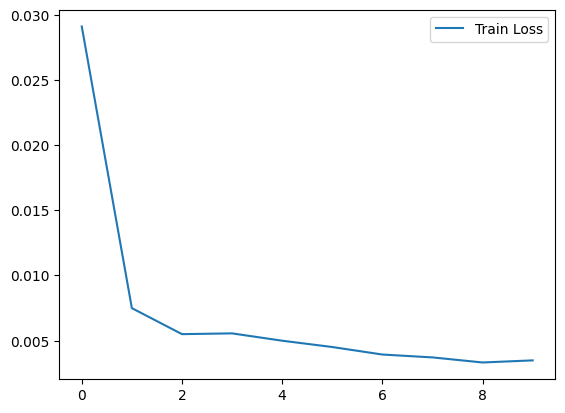

In [ ]:
sns.lineplot(hist.history["loss"],
             label = "Train Loss")

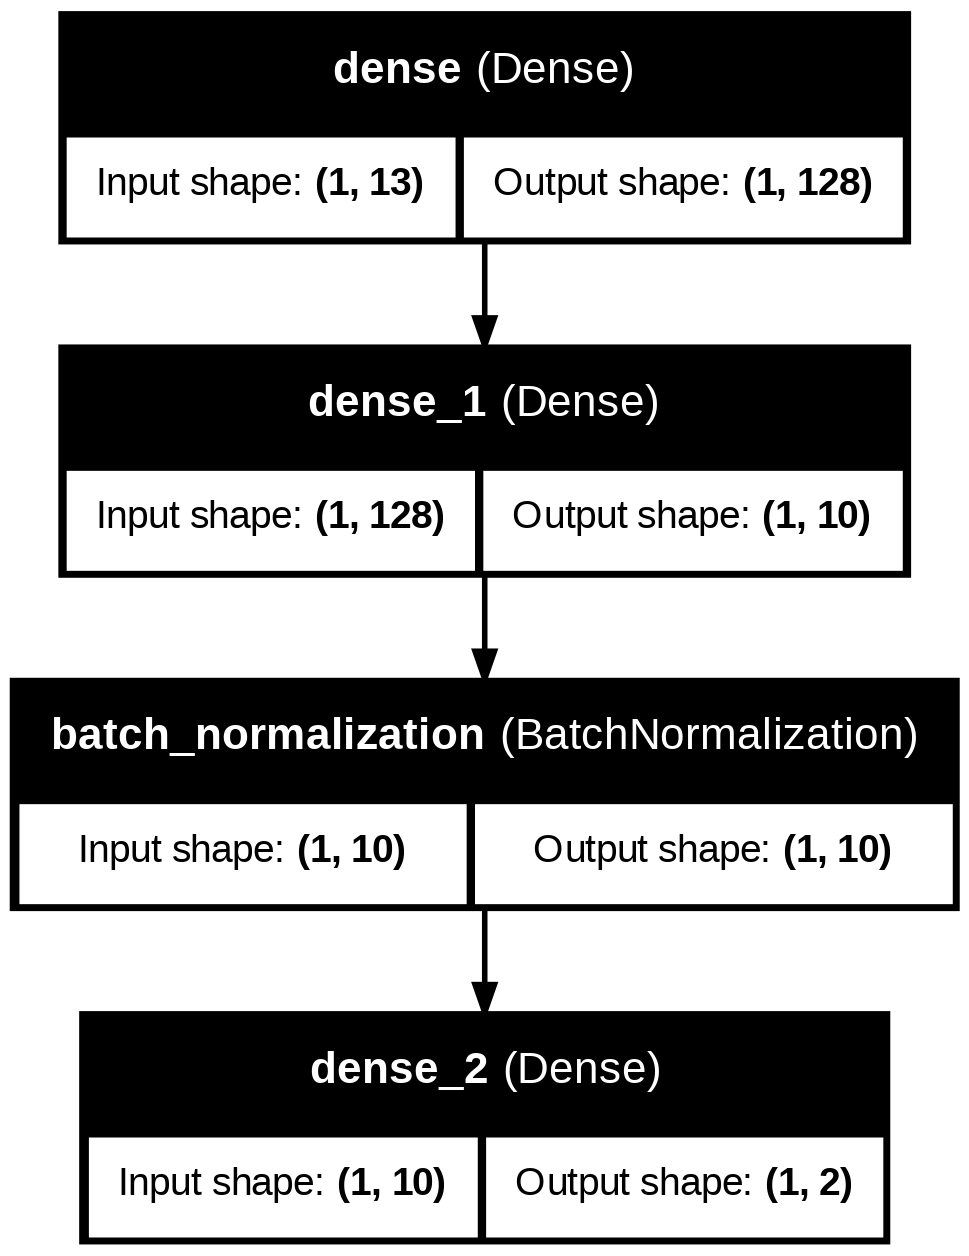

In [ ]:
plot_model(model,
           show_shapes = True,
           show_layer_names = True)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpbblwfpxt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 13), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  133396395251216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395253712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395253520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395254288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395248336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395254096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395255440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395254864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395255632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133396395256208: TensorSpec(shape=(), dtype=tf.resource, name=None)
